<a href="https://colab.research.google.com/github/hsnhafsah/ICS3203-CAT2-Assembly-NetiahHafsahSiti-143758/blob/main/TrafficLightOptimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 # Update package lists
!apt-get update -qq

# Install SUMO, SUMO tools, and documentation
!apt-get install -y sumo sumo-tools sumo-doc

# Install Python libraries
!pip install -q sumolib matplotlib pandas
!pip install sumolib traci gymnasium stable-baselines3 matplotlib pandas

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  binfmt-support fastjar fonts-roboto-unhinted jarwrapper javascript-common libcoin80c
  libcollada-dom2.5-dp0 libfox-1.6-0 libgdal30 libglu1-mesa libjs-openlayers liblua5.2-0
  libopenscenegraph161 libopenthreads21 libpoppler-glib8 libproj22 proj-bin
Suggested packages:
  apache2 | lighttpd | httpd libopenal0a libsimage-dev libbullet2
The following NEW packages will be installed:
  binfmt-support fastjar fonts-roboto-unhinted jarwrapper javascript-common libcoin80c
  libcollada-dom2.5-dp0 libfox-1.6-0 libgdal30 libglu1-mesa libjs-openlayers liblua5.2-0
  libopenscenegraph161 libopenthreads21 libpoppler-glib8 libproj22 proj-bin sumo sumo-doc
  sumo-tool

# Declaring Routes and Nodes

In [ ]:
import os
import shutil

# Define the network directory path
network_dir = "/content/sumo_network"

# Check if the directory exists
if os.path.exists(network_dir):
    # Remove the directory and all its contents
    shutil.rmtree(network_dir)
    print(f"Network directory '{network_dir}' has been deleted successfully.")
else:
    print(f"Network directory '{network_dir}' does not exist.")


Network directory '/content/sumo_network' does not exist.


In [ ]:
import os
import sys
import subprocess
import matplotlib.pyplot as plt
import sumolib
import traci
import gymnasium as gym
from stable_baselines3 import DQN
from gymnasium import spaces
import numpy as np
import pandas as pd

# Define SUMO installation path
sumo_home = '/usr/share/sumo'

# Check if SUMO_HOME exists
if os.path.exists(sumo_home):
    os.environ['SUMO_HOME'] = sumo_home
    print(f"SUMO_HOME set to: {sumo_home}")
else:
    raise EnvironmentError("SUMO_HOME path not found. Please verify SUMO installation.")

# Append SUMO's tools directory to Python path
tools = os.path.join(sumo_home, "tools")
if tools not in sys.path:
    sys.path.append(tools)
    print(f"Appended SUMO tools path to sys.path: {tools}")
else:
    print("SUMO tools path already in sys.path.")

SUMO_HOME set to: /usr/share/sumo
Appended SUMO tools path to sys.path: /usr/share/sumo/tools


In [ ]:
import os

# Create network directory
network_dir = "/content/sumo_network"
os.makedirs(network_dir, exist_ok=True)

# Define nodes representing the intersection
nodes = """
<nodes>
    <node id="uhuru_west" x="-500" y="0" type="priority"/>
    <node id="uhuru_east" x="500" y="0" type="priority"/>
    <node id="haile_south" x="0" y="-500" type="priority"/>
    <node id="haile_north" x="0" y="500" type="priority"/>
    <node id="intersection" x="0" y="0" type="traffic_light"/>
</nodes>

"""

# Save nodes to file
with open(os.path.join(network_dir, "nodes.nod.xml"), "w") as f:
    f.write(nodes)

print("Nodes defined and saved successfully.")


Nodes defined and saved successfully.


In [ ]:
# Define edges connecting the nodes
edges = """
<edges>
    <!-- Uhuru Road (East-West Direction) -->
    <edge id="uhuru_west_to_intersection" from="uhuru_west" to="intersection" numLanes="1" speed="13.89"/>
    <edge id="intersection_to_uhuru_west" from="intersection" to="uhuru_west" numLanes="1" speed="13.89"/>
    <edge id="intersection_to_uhuru_east" from="intersection" to="uhuru_east" numLanes="1" speed="13.89"/>
    <edge id="uhuru_east_to_intersection" from="uhuru_east" to="intersection" numLanes="1" speed="13.89"/>

    <!-- Haile Selassie Road (North-South Direction) -->
    <edge id="haile_south_to_intersection" from="haile_south" to="intersection" numLanes="1" speed="13.89"/>
    <edge id="intersection_to_haile_south" from="intersection" to="haile_south" numLanes="1" speed="13.89"/>
    <edge id="intersection_to_haile_north" from="intersection" to="haile_north" numLanes="1" speed="13.89"/>
    <edge id="haile_north_to_intersection" from="haile_north" to="intersection" numLanes="1" speed="13.89"/>
</edges>
"""

# Save edges to file
with open(os.path.join(network_dir, "edges.edg.xml"), "w") as f:
    f.write(edges)

print("Edges defined and saved successfully.")


Edges defined and saved successfully.


In [ ]:
# Define vehicle types
vtypes = """
<types>
    <type id="car" vClass="passenger" accel="2.6" decel="4.5"
          length="5.0" minGap="2.5" maxSpeed="13.89" sigma="0.5"/>
</types>
"""

# Save vehicle types to file
with open(os.path.join(network_dir, "vtypes.type.xml"), "w") as f:
    f.write(vtypes)

print("Vehicle types defined and saved successfully.")




Vehicle types defined and saved successfully.


In [ ]:
# Generate the network file
net_file = os.path.join(network_dir, "network.net.xml")

# Define network configuration
netccfg = f"""
<configuration>
    <input>
        <node-files value="{os.path.join(network_dir, 'nodes.nod.xml')}"/>
        <edge-files value="{os.path.join(network_dir, 'edges.edg.xml')}"/>
        <type-files value="{os.path.join(network_dir, 'vtypes.type.xml')}"/>
    </input>
    <output>
        <output-file value="{net_file}"/>
    </output>
</configuration>
"""

# Save network configuration to file
with open(os.path.join(network_dir, "network.netccfg"), "w") as f:
    f.write(netccfg)

print("Network configuration defined and saved successfully.")

# Run netconvert to generate the network
os.system(f"netconvert -c {os.path.join(network_dir, 'network.netccfg')} -o {net_file}")


Network configuration defined and saved successfully.


35584

In [ ]:
!netconvert --node-files /content/sumo_network/nodes.nod.xml \
           --edge-files /content/sumo_network/edges.edg.xml \
           --type-files /content/sumo_network/vtypes.type.xml \
           --output-file /content/sumo_network/network.net.xml \
           --no-turnarounds --tls.guess=false --verbose


Parsing types from '/content/sumo_network/vtypes.type.xml' ... done.
Parsing nodes from '/content/sumo_network/nodes.nod.xml' ... done.
Parsing edges from '/content/sumo_network/edges.edg.xml' ... done.
 Import done:
   5 nodes loaded.
   1 types loaded.
   8 edges loaded.
Removing self-loops ... done (0ms).
Removing empty nodes ... done (1ms).
   0 nodes removed.
Moving network to origin ... done (0ms).
Computing turning directions ... done (0ms).
Assigning nodes to traffic lights ... done (0ms).
Sorting nodes' edges ... done (0ms).
Computing node shapes ... done (0ms).
Computing edge shapes ... done (0ms).
Computing node types ... done (0ms).
Computing priorities ... done (0ms).
Computing approached edges ... done (0ms).
Guessing and setting roundabouts ... done (0ms).
Computing approaching lanes ... done (0ms).
Dividing of lanes on approached lanes ... done (0ms).
Processing turnarounds ... done (0ms).
Rechecking of lane endings ... done (0ms).
Computing traffic light control inform

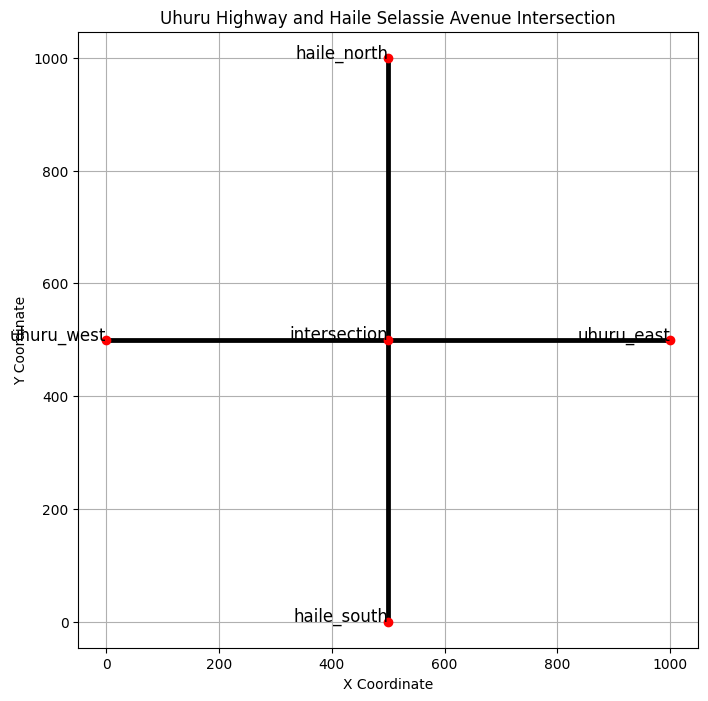

In [ ]:
# Load the network
net = sumolib.net.readNet(net_file)

# Extract node positions
nodes = net.getNodes()
node_positions = {node.getID(): node.getCoord() for node in nodes}

# Extract edges
edges = net.getEdges()

# Plot the network
plt.figure(figsize=(8, 8))
for edge in edges:
    shape = edge.getShape()
    x_values = [point[0] for point in shape]
    y_values = [point[1] for point in shape]
    plt.plot(x_values, y_values, 'k-', linewidth=2)

# Annotate nodes
for node_id, (x, y) in node_positions.items():
    plt.plot(x, y, 'ro')
    plt.text(x, y, node_id, fontsize=12, ha='right')

plt.title('Uhuru Highway and Haile Selassie Avenue Intersection')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid(True)
plt.axis('equal')
plt.show()


In [ ]:
# Define routes
routes = """
<routes>
    <!-- Vehicle Type -->
    <vType id="car" vClass="passenger" accel="2.6" decel="4.5"
           length="5.0" minGap="2.5" maxSpeed="13.89" sigma="0.5"/>

    <!-- Uhuru Road Routes -->
    <!-- From Uhuru West -->
    <route id="uhuru_west_to_uhuru_east" edges="uhuru_west_to_intersection intersection_to_uhuru_east"/>
    <route id="uhuru_west_to_haile_north" edges="uhuru_west_to_intersection intersection_to_haile_north"/>
    <route id="uhuru_west_to_haile_south" edges="uhuru_west_to_intersection intersection_to_haile_south"/>

    <!-- From Uhuru East -->
    <route id="uhuru_east_to_uhuru_west" edges="uhuru_east_to_intersection intersection_to_uhuru_west"/>
    <route id="uhuru_east_to_haile_south" edges="uhuru_east_to_intersection intersection_to_haile_south"/>
    <route id="uhuru_east_to_haile_north" edges="uhuru_east_to_intersection intersection_to_haile_north"/>

    <!-- Haile Selassie Road Routes -->
    <!-- From Haile North -->
    <route id="haile_north_to_haile_south" edges="haile_north_to_intersection intersection_to_haile_south"/>
    <route id="haile_north_to_uhuru_east" edges="haile_north_to_intersection intersection_to_uhuru_east"/>
    <route id="haile_north_to_uhuru_west" edges="haile_north_to_intersection intersection_to_uhuru_west"/>

    <!-- From Haile South -->
    <route id="haile_south_to_haile_north" edges="haile_south_to_intersection intersection_to_haile_north"/>
    <route id="haile_south_to_uhuru_west" edges="haile_south_to_intersection intersection_to_uhuru_west"/>
    <route id="haile_south_to_uhuru_east" edges="haile_south_to_intersection intersection_to_uhuru_east"/>

    <!-- Flows -->
    <!-- Uhuru Road Flows -->
    <flow id="flow_uhuru_west_east" type="car" route="uhuru_west_to_uhuru_east" begin="0" end="3600" probability="0.05"/>
    <flow id="flow_uhuru_west_north" type="car" route="uhuru_west_to_haile_north" begin="0" end="3600" probability="0.02"/>
    <flow id="flow_uhuru_west_south" type="car" route="uhuru_west_to_haile_south" begin="0" end="3600" probability="0.03"/>

    <flow id="flow_uhuru_east_west" type="car" route="uhuru_east_to_uhuru_west" begin="0" end="3600" probability="0.05"/>
    <flow id="flow_uhuru_east_south" type="car" route="uhuru_east_to_haile_south" begin="0" end="3600" probability="0.02"/>
    <flow id="flow_uhuru_east_north" type="car" route="uhuru_east_to_haile_north" begin="0" end="3600" probability="0.03"/>

    <!-- Haile Selassie Road Flows -->
    <flow id="flow_haile_north_south" type="car" route="haile_north_to_haile_south" begin="0" end="3600" probability="0.05"/>
    <flow id="flow_haile_north_east" type="car" route="haile_north_to_uhuru_east" begin="0" end="3600" probability="0.02"/>
    <flow id="flow_haile_north_west" type="car" route="haile_north_to_uhuru_west" begin="0" end="3600" probability="0.03"/>

    <flow id="flow_haile_south_north" type="car" route="haile_south_to_haile_north" begin="0" end="3600" probability="0.05"/>
    <flow id="flow_haile_south_west" type="car" route="haile_south_to_uhuru_west" begin="0" end="3600" probability="0.02"/>
    <flow id="flow_haile_south_east" type="car" route="haile_south_to_uhuru_east" begin="0" end="3600"  probability="0.03"/>
</routes>
"""

# Save routes to file
with open(os.path.join(network_dir, "routes.rou.xml"), "w") as f:
    f.write(routes)

print("Routes defined and saved successfully.")


Routes defined and saved successfully.


<additional>
    <tlLogic id="intersection" type="static" programID="1" offset="0">
        <!-- Phase 1: Uhuru Highway Green, Haile Selassie Red -->
        <phase duration="30" state="GrGr"/>
        <!-- Phase 2: Yellow for Uhuru Highway -->
        <phase duration="3" state="yryr"/>
        <!-- Phase 3: Uhuru Highway Red, Haile Selassie Green -->
        <phase duration="30" state="rGrG"/>
        <!-- Phase 4: Yellow for Haile Selassie Avenue -->
        <phase duration="3" state="ryry"/>
    </tlLogic>
</additional>


In [ ]:
# Define SUMO configuration
sumocfg = f"""
<configuration>
    <input>
        <net-file value="{net_file}"/>
        <route-files value="{os.path.join(network_dir, 'routes.rou.xml')}"/>
    </input>
    <time>
        <begin value="0"/>
        <end value="3600"/>
        <step-length value="1"/>
    </time>
</configuration>
"""

# Save configuration to file
sumocfg_file = os.path.join(network_dir, "simulation.sumocfg")
with open(sumocfg_file, "w") as f:
    f.write(sumocfg)
print("SUMO configuration file created successfully.")


SUMO configuration file created successfully.


In [ ]:
!sumo -c /content/sumo_network/simulation.sumocfg


Step #3600.00 (0ms ?*RT. ?UPS, vehicles TOT 1388 ACT 56 BUF 0)                            


# Initial Simulation without Training


No active TraCI connection to close.
 Retrying in 1 seconds
TraCI started.
Available edge IDs: (':intersection_0', ':intersection_1', ':intersection_10', ':intersection_11', ':intersection_12', ':intersection_13', ':intersection_14', ':intersection_15', ':intersection_2', ':intersection_3', ':intersection_4', ':intersection_5', ':intersection_6', ':intersection_7', ':intersection_8', ':intersection_9', 'haile_north_to_intersection', 'haile_south_to_intersection', 'intersection_to_haile_north', 'intersection_to_haile_south', 'intersection_to_uhuru_east', 'intersection_to_uhuru_west', 'uhuru_east_to_intersection', 'uhuru_west_to_intersection')
Available traffic light IDs: ('intersection',)
Step: 600, Vehicles: 51, Waiting Time: 95.0
Step: 1200, Vehicles: 44, Waiting Time: 153.0
Step: 1800, Vehicles: 40, Waiting Time: 172.0
Step: 2400, Vehicles: 52, Waiting Time: 42.0
Step: 3000, Vehicles: 36, Waiting Time: 54.0
Step: 3600, Vehicles: 56, Waiting Time: 222.0
TraCI closed.


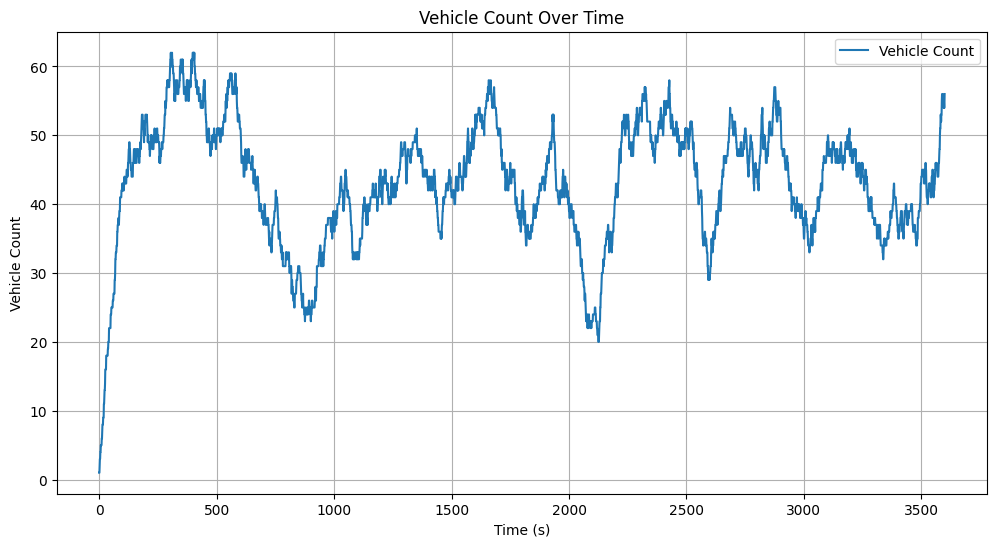

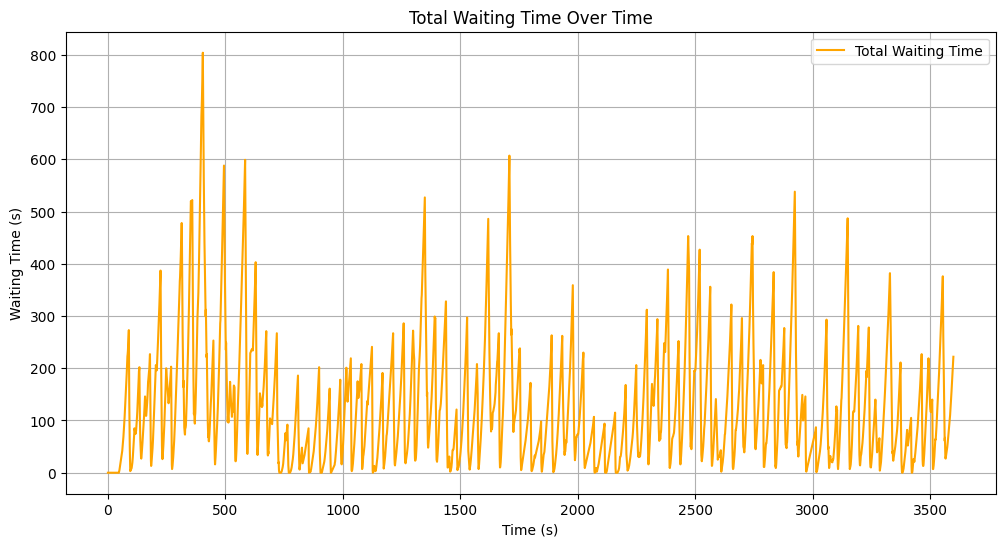

In [ ]:
import traci
import matplotlib.pyplot as plt

# Function to run the simulation with TraCI and collect data
def run_simulation_with_traci():
    sumo_binary = "sumo"  # Use "sumo-gui" if you want to visualize the simulation
    sumo_cmd = [sumo_binary, "-c", sumocfg_file, "--no-step-log", "--no-warnings"]

    # Close any active TraCI session
    try:
        traci.close()
    except traci.FatalTraCIError:
        print("No active TraCI connection to close.")

    try:
        # Start TraCI
        traci.start(sumo_cmd)
        print("TraCI started.")

        edge_ids = traci.edge.getIDList()
        print(f"Available edge IDs: {edge_ids}")

        tl_ids = traci.trafficlight.getIDList()
        print(f"Available traffic light IDs: {tl_ids}")


        # Initialize data storage
        vehicle_counts = []
        waiting_times = []
        time_steps = []

        # Run the simulation for 3600 steps (1 hour)
        for step in range(3600):
            traci.simulationStep()

            # Get current vehicle count and total waiting time
            vehicle_count = traci.vehicle.getIDCount()
            waiting_time = sum(traci.vehicle.getWaitingTime(veh) for veh in traci.vehicle.getIDList())

            # Collect data
            vehicle_counts.append(vehicle_count)
            waiting_times.append(waiting_time)
            time_steps.append(step)

            # Print progress every 600 steps (10 minutes)
            if (step + 1) % 600 == 0:
                print(f"Step: {step + 1}, Vehicles: {vehicle_count}, Waiting Time: {waiting_time}")

    except Exception as e:
        print(f"Error during simulation: {e}")
    finally:
        # Close TraCI connection
        try:
            traci.close()
            print("TraCI closed.")
        except traci.FatalTraCIError:
            print("TraCI connection was already closed.")

    # Check if data was collected
    if not time_steps:
        print("No simulation data collected. Exiting.")
        return


    # Plot results: Vehicle Count Over Time
    plt.figure(figsize=(12, 6))
    plt.plot(time_steps, vehicle_counts, label='Vehicle Count')
    plt.xlabel('Time (s)')
    plt.ylabel('Vehicle Count')
    plt.title('Vehicle Count Over Time')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot results: Waiting Time Over Time
    plt.figure(figsize=(12, 6))
    plt.plot(time_steps, waiting_times, label='Total Waiting Time', color='orange')
    plt.xlabel('Time (s)')
    plt.ylabel('Waiting Time (s)')
    plt.title('Total Waiting Time Over Time')
    plt.legend()
    plt.grid(True)
    plt.show()

# Uncomment to run the simulation with data collection
run_simulation_with_traci()


In [ ]:
!pip install "stable-baselines3[extra]>=2.0.0" gymnasium shimmy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 26.7 MB/s eta 0:00:00


# Training the dataset with the Deep Q-Network (DQN) model

 Retrying in 1 seconds
TraCI connection established.
Using cpu device
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1e+03    |
|    ep_rew_mean      | -8.3e+03 |
|    exploration_rate | 0.62     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 395      |
|    time_elapsed     | 10       |
|    total_timesteps  | 4000     |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 43.3     |
|    n_updates        | 749      |
----------------------------------
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 1e+03     |
|    ep_rew_mean      | -1.45e+04 |
|    exploration_rate | 0.24      |
| time/               |           |
|    episodes         | 8         |
|    fps              | 375       |
|    time_elapsed     | 21        |
|    total_timesteps  | 8000      |
| train/  

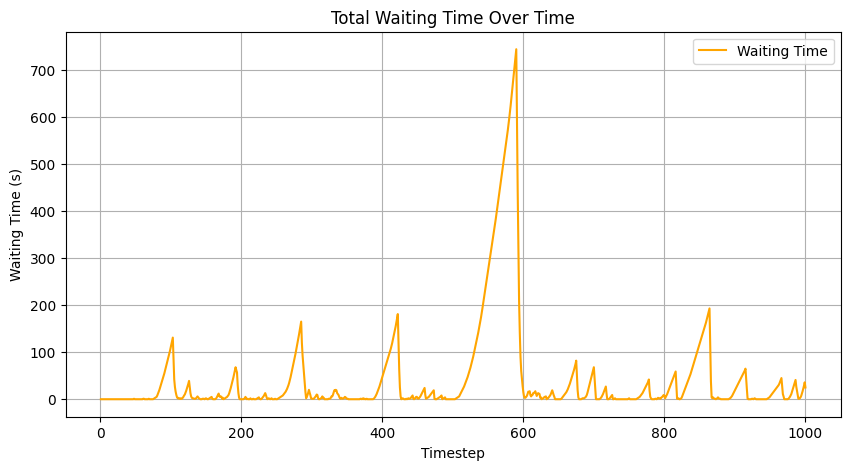

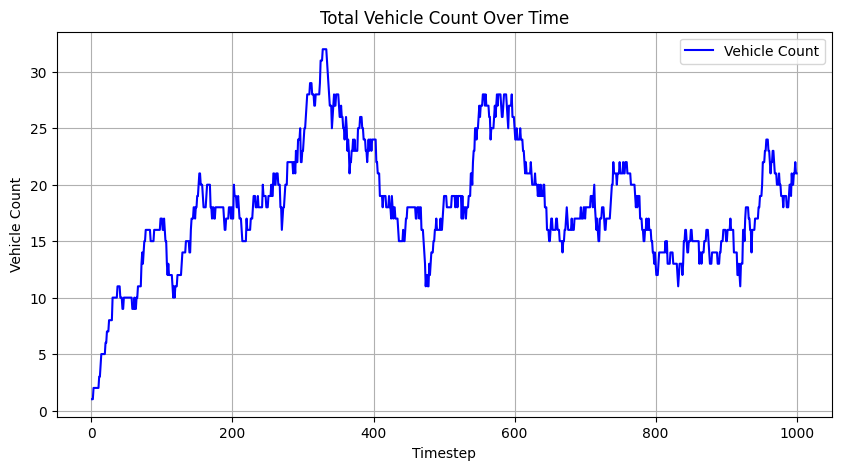

In [ ]:
import traci
import matplotlib.pyplot as plt
import csv
import os
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
import pandas as pd

class TrafficSignalEnv(gym.Env):
    def __init__(self, traffic_light_id="intersection", max_steps=1000):
        super(TrafficSignalEnv, self).__init__()
        self.traffic_light_id = traffic_light_id
        self.max_steps = max_steps
        self.step_count = 0

        # Define action and observation space
        self.action_space = spaces.Discrete(2)  # Actions: 0 - EW Green, NS Red; 1 - EW Red, NS Green
        self.observation_space = spaces.Box(low=0, high=1000, shape=(2,), dtype=np.float32)

        self.observation_space = spaces.Box(low=0, high=1000, shape=(2,), dtype=np.float32)

    def reset(self, seed=None, options=None):
        self.step_count = 0
        self.prev_total_queue_length = 0  # Reset previous queue length

        traci.load(["-c", sumocfg_file, "--step-length", "1"])
        traci.simulationStep()

        # Retrieve controlled links
        controlled_links = traci.trafficlight.getControlledLinks(self.traffic_light_id)
        return self._get_state(), {}

    def _get_state(self):
        ew_vehicle_count = traci.edge.getLastStepVehicleNumber("uhuru_west_to_intersection") + \
                          traci.edge.getLastStepVehicleNumber("uhuru_east_to_intersection")
        ns_vehicle_count = traci.edge.getLastStepVehicleNumber("haile_south_to_intersection") + \
                          traci.edge.getLastStepVehicleNumber("haile_north_to_intersection")
        return np.array([ew_vehicle_count, ns_vehicle_count], dtype=np.float32)



    def _compute_reward(self):
        """
        Computes the reward for the current state of the environment.
        The reward aims to minimize total waiting time and queue lengths,
        and provides positive feedback when improvements are made.
        """
        # List of edges approaching the intersection
        incoming_edges = [
            "uhuru_west_to_intersection",
            "uhuru_east_to_intersection",
            "haile_south_to_intersection",
            "haile_north_to_intersection"
        ]

        # Calculate total waiting time and queue lengths
        total_waiting_time = sum(traci.edge.getWaitingTime(edge) for edge in incoming_edges)
        total_queue_length = sum(traci.edge.getLastStepHaltingNumber(edge) for edge in incoming_edges)

        # Reward components
        waiting_time_penalty = - total_waiting_time
        queue_length_penalty = - (total_queue_length * 10)

        # Positive reward for reducing queue lengths
        queue_length_reduction = self.prev_total_queue_length - total_queue_length
        queue_reduction_reward = 50 * queue_length_reduction  # Reward per vehicle reduction

        # Update previous queue length
        self.prev_total_queue_length = total_queue_length

        # Total reward
        reward = waiting_time_penalty + queue_length_penalty + queue_reduction_reward

        return reward

    def step(self, action):
        # Apply action to traffic light
        self._take_action(action)

        # Advance simulation
        traci.simulationStep()

        # Get new state and reward
        state = self._get_state()
        reward = self._compute_reward()

        self.step_count += 1
        done = self.step_count >= self.max_steps

        return state, reward, done, False, {}

    def _take_action(self, action):
        """
        Sets the traffic light phase based on the chosen action.
        Actions:
        - 0: Uhuru Road Green; Haile Selassie Road Red
        - 1: Uhuru Road Red; Haile Selassie Road Green
        """
        # Convert action to integer in case it's a numpy array
        action = int(action)

        # Define traffic light phases
        phases = {
            0: 'rrrGGGrrrGGG',  # Uhuru Green, Haile Red
            1: 'GGGrrrGGGrrr'   # Uhuru Red, Haile Green
        }

        # Ensure action is valid
        if action not in phases:
            raise ValueError(f"Invalid action: {action}. Expected 0 or 1.")

        # Set the traffic light phase
        try:
            traci.trafficlight.setRedYellowGreenState(self.traffic_light_id, phases[action])
        except traci.TraCIException as e:
            print(f"Error setting traffic light phase: {e}")
            traci.close()
            raise


    def render(self, mode='human'):
        pass

    def close(self):
        try:
            traci.close()
            print("TraCI connection closed.")
        except Exception as e:
            print(f"Error closing TraCI connection: {e}")

# Utility Functions
def start_traci():
    sumo_binary = "sumo"
    sumo_cmd = [sumo_binary, "-c", sumocfg_file, "--no-step-log", "--no-warnings"]
    traci.start(sumo_cmd)
    print("TraCI connection established.")

def train_dqn_model():
    start_traci()
    env = Monitor(TrafficSignalEnv(traffic_light_id="intersection", max_steps=1000))
    model = DQN(
        "MlpPolicy",
        env,
        verbose=1,
        learning_rate=1e-4,
        gamma=0.95,
        buffer_size=10000,        # Increased buffer size for better experience replay
        learning_starts=1000,     # Delay learning to populate the buffer
        batch_size=32,            # Set a reasonable batch size
        target_update_interval=500,  # Update target network less frequently
        train_freq=4,             # Train every 4 steps
    )
    try:
        model.learn(total_timesteps=100000)  # Increased total timesteps for better learning
    finally:
        env.close()
    model_path = os.path.join(network_dir, "dqn_traffic_model")
    model.save(model_path)
    print(f"Model trained and saved to {model_path}.")


def evaluate_model():
    model_path = os.path.join(network_dir, "dqn_traffic_model")
    model = DQN.load(model_path)
    start_traci()
    env = TrafficSignalEnv(traffic_light_id="intersection", max_steps=1000)
    obs = env.reset()[0]
    done = False

    waiting_times, vehicle_counts, time_steps = [], [], []
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _, _ = env.step(action)
        vehicle_count = traci.edge.getLastStepVehicleNumber("uhuru_west_to_intersection") + \
                        traci.edge.getLastStepVehicleNumber("intersection_to_uhuru_east") + \
                        traci.edge.getLastStepVehicleNumber("haile_south_to_intersection") + \
                        traci.edge.getLastStepVehicleNumber("intersection_to_haile_north")
        waiting_time = sum([traci.vehicle.getWaitingTime(veh) for veh in traci.vehicle.getIDList()])
        time_steps.append(env.step_count)
        vehicle_counts.append(vehicle_count)
        waiting_times.append(waiting_time)

    env.close()

    # Plot waiting times
    plt.figure(figsize=(10, 5))
    plt.plot(time_steps, waiting_times, label='Waiting Time', color='orange')
    plt.xlabel('Timestep')
    plt.ylabel('Waiting Time (s)')
    plt.title('Total Waiting Time Over Time')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot vehicle counts
    plt.figure(figsize=(10, 5))
    plt.plot(time_steps, vehicle_counts, label='Vehicle Count', color='blue')
    plt.xlabel('Timestep')
    plt.ylabel('Vehicle Count')
    plt.title('Total Vehicle Count Over Time')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Calculate performance metrics
    avg_vehicle_count = sum(vehicle_counts) / len(vehicle_counts) if vehicle_counts else 0
    avg_waiting_time = sum(waiting_times) / len(waiting_times) if waiting_times else 0

    model_performance = {
        "Average Vehicle Count": f"{avg_vehicle_count:.2f}",
        "Average Waiting Time": f"{avg_waiting_time:.2f} seconds"
    }



# Execution
if __name__ == "__main__":
    train_dqn_model()
    evaluate_model()